In [2]:
!mamba install pandas numpy matplotlib seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 4.2805 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2                

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetic_data.csv')
print(df.head())
print(df.shape)
print(df.dtypes)

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [5]:
print(df.isnull().sum())

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [9]:
# Drop rows where readmission column is missing
df = df.dropna(subset=['readmitted'])  # Replace 'readmitted' with your target column name

# Fill other missing values with 0
df = df.fillna(0)

In [10]:
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (101766, 50)


In [11]:
# Convert age to numeric if it's text
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# If you have a date column, convert it
# df['date_column'] = pd.to_datetime(df['date_column'])

print(df.dtypes)

encounter_id                  int64
patient_nbr                   int64
race                            str
gender                          str
age                         float64
weight                          str
admission_type_id             int64
discharge_disposition_id      int64
admission_source_id           int64
time_in_hospital              int64
payer_code                      str
medical_specialty               str
num_lab_procedures            int64
num_procedures                int64
num_medications               int64
number_outpatient             int64
number_emergency              int64
number_inpatient              int64
diag_1                          str
diag_2                          str
diag_3                          str
number_diagnoses              int64
max_glu_serum                object
A1Cresult                    object
metformin                       str
repaglinide                     str
nateglinide                     str
chlorpropamide              

In [12]:
# Just remove rows where age > 100 (obviously wrong)
df = df[df['age'] < 100]

In [15]:
# Example: Create a column showing if patient is old
df['is_old'] = df['age'] > 65

# Example: Create age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 70, 100], labels=['Young', 'Middle', 'Senior', 'Elderly'])

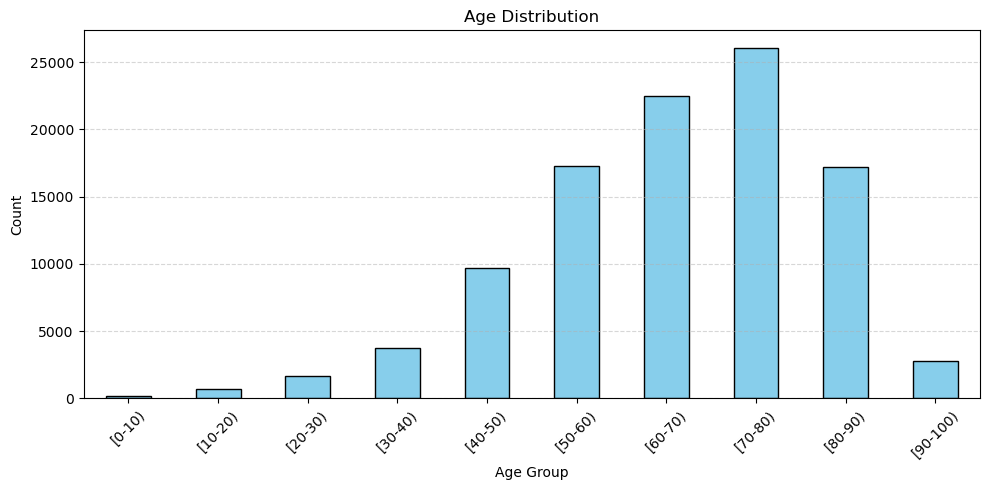

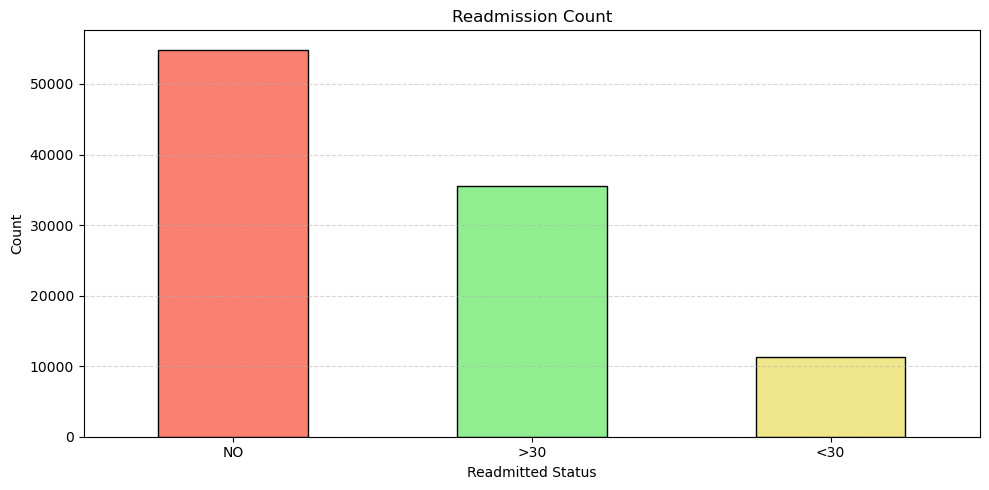

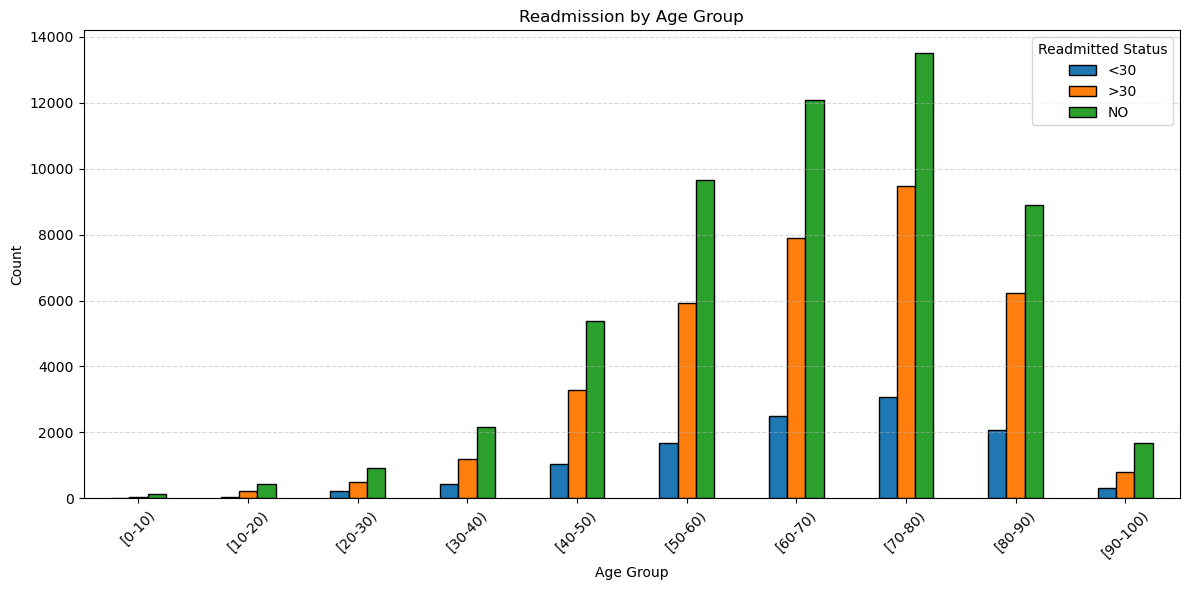

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reload the fresh dataset to ensure all 101,766 rows are active
df = pd.read_csv('diabetic_data.csv')

# =========================================================
# CHART 1: Age Distribution
# =========================================================
plt.figure(figsize=(10, 5))
df['age'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('01_age_distribution.png')
plt.show()

# =========================================================
# CHART 2: Readmission Count
# =========================================================
plt.figure(figsize=(10, 5))
df['readmitted'].value_counts().plot(kind='bar', color=['salmon', 'lightgreen', 'khaki'], edgecolor='black')
plt.title('Readmission Count')
plt.xlabel('Readmitted Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('02_readmission.png')
plt.show()

# =========================================================
# CHART 3: Readmission by Age Group
# =========================================================
# We create a separate figure size inside the pandas plot engine for layout sizing
df.groupby('age')['readmitted'].value_counts().unstack().plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Readmission by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Readmitted Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('03_readmission_by_age.png')
plt.show()


In [4]:
import pandas as pd

df = pd.read_csv('diabetic_data.csv')

# Total patients
print("Total patients:", df.shape[0])

# Total columns
print("Total columns:", df.shape[1])

# Readmission count
print("\nReadmission breakdown:")
print(df['readmitted'].value_counts())

# Readmission percentage
readmitted_pct = (df['readmitted'].value_counts() / len(df) * 100).round(2)
print("\nReadmission percentage:")
print(readmitted_pct)

Total patients: 101766
Total columns: 50

Readmission breakdown:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Readmission percentage:
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: count, dtype: float64
